In [224]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd

dir = '/Users/fynn/Desktop/Uni/Master/Masters-thesis/04 Mathematica/0 Kernels/kernels_real/data'

def clean_mathematica_number(s):
    return float(s[:-4])  # Remove first char and last 3 chars (`10)



def abs_sq(q):
    return np.sum(q**2, axis=-1)

def dot(q1, q2):
    return np.sum(q1*q2, axis=-1)

def get_F(exp_file, k12, k22, k32, q2, k1mq2, k2pq2, k3mq2):
    F_exps_mathematica = np.array(pd.read_csv(exp_file, sep='\s+', names=["k12", "k22", "k32", "k1mq2", "q2", "k2pq2", "swapIndex", "coeff"]))

    exp_k12 = F_exps_mathematica[:,0]
    exp_k22 = F_exps_mathematica[:,1]
    exp_k32 = F_exps_mathematica[:,2]
    exp_k1mq2 = F_exps_mathematica[:,3]
    exp_q2 = F_exps_mathematica[:,4]
    exp_k2pq2 = F_exps_mathematica[:,5]
    swap_index = F_exps_mathematica[:,6]
    coeffs = F_exps_mathematica[:,7]
    


    F = 0
    for i in range(len(coeffs)):
        if exp_k12[i] + exp_k22[i] + exp_k32[i] + exp_q2[i] + exp_k1mq2[i] + exp_k2pq2[i] != 0:
            print(f"problematic terms: {i}, exps_sum = {exp_k12[i] + exp_k22[i] + exp_k32[i] + exp_q2[i] + exp_k1mq2[i] + exp_k2pq2[i]}")
        if exp_q2[i] + exp_k1mq2[i] + exp_k2pq2[i] > 0:
            print(f"divergent term: i={i}", exp_q2[i], exp_k1mq2[i], exp_k2pq2[i])

        if swap_index[i]==0:
            term = coeffs[i] * k12**exp_k12[i] * k22**exp_k22[i] * k32**exp_k32[i] * q2**exp_q2[i] * k1mq2**exp_k1mq2[i] * k2pq2**exp_k2pq2[i]
            F += term
        elif swap_index[i]==1:
            term = coeffs[i] * k12**exp_k12[i] * k22**exp_k22[i] * k32**exp_k32[i] * k2pq2**exp_q2[i] * k3mq2**exp_k1mq2[i] * q2**exp_k2pq2[i]
            F += term
    return F



def get_F_UV(exp_file, k12, k22, k32, q2, k1mq2, k2pq2, k3mq2):
    F_exps_mathematica = np.array(pd.read_csv(exp_file, sep='\s+', names=["k12", "k22", "k32", "k1mq2", "q2", "k2pq2", "swapIndex", "coeff"]))

    exp_k12 = F_exps_mathematica[:,0]
    exp_k22 = F_exps_mathematica[:,1]
    exp_k32 = F_exps_mathematica[:,2]
    exp_k1mq2 = F_exps_mathematica[:,3]
    exp_q2 = F_exps_mathematica[:,4]
    exp_k2pq2 = F_exps_mathematica[:,5]
    swap_index = F_exps_mathematica[:,6]
    coeffs = F_exps_mathematica[:,7]
    

    F = 0
    F_list = []
    for i in range(len(coeffs)):
        if exp_k12[i] + exp_k22[i] + exp_k32[i] + exp_q2[i] + exp_k1mq2[i] + exp_k2pq2[i] != 0:
            print(f"problematic terms: {i}, exps_sum = {exp_k12[i] + exp_k22[i] + exp_k32[i] + exp_q2[i] + exp_k1mq2[i] + exp_k2pq2[i]}")
        if exp_q2[i] + exp_k1mq2[i] + exp_k2pq2[i] > 0:
            F_list.append(F_exps_mathematica[i])

            if swap_index[i]==0:
                term = coeffs[i] * k12**exp_k12[i] * k22**exp_k22[i] * k32**exp_k32[i] * q2**exp_q2[i] * k1mq2**exp_k1mq2[i] * k2pq2**exp_k2pq2[i]
                F += term
            elif swap_index[i]==1:
                term = coeffs[i] * k12**exp_k12[i] * k22**exp_k22[i] * k32**exp_k32[i] * k2pq2**exp_q2[i] * k3mq2**exp_k1mq2[i] * q2**exp_k2pq2[i]
                F += term
    return F, F_list


def compare(x, y1, y2, label_y1, label_y2, ylabel):
    res = 1 - y1/y2

    print("factor = ",np.mean(y1/y2))

    fig = plt.figure(figsize=(8, 6))
    gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.2)

    ax1 = fig.add_subplot(gs[0])
    ax1.plot(x, y1, label=label_y1)
    ax1.plot(x, y2, label=label_y2)
    ax1.set_ylabel(rf"${ylabel}$")
    ax1.legend()
    ax1.grid()

    # Residual plot (same x-axis)
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.axhline(0, color='black', linestyle='--', linewidth=1)
    ax2.plot(x, res, color='black', label="Residuals")
    ax2.set_xlabel(rf"k $\left[h/\mathrm{{Mpc}}\right]$")
    ax2.set_ylabel(r"Res. $\%$")
    ax2.set_xscale("log")
    ax2.grid()

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:51: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:51: SyntaxWarning: invalid escape sequence '\s'
/var/folders/1t/6lvnjwb12mq1gyh7dlscmql00000gn/T/ipykernel_26808/1248056031.py:20: SyntaxWarning: invalid escape sequence '\s'
  F_exps_mathematica = np.array(pd.read_csv(exp_file, sep='\s+', names=["k12", "k22", "k32", "k1mq2", "q2", "k2pq2", "swapIndex", "coeff"]))
/var/folders/1t/6lvnjwb12mq1gyh7dlscmql00000gn/T/ipykernel_26808/1248056031.py:51: SyntaxWarning: invalid escape sequence '\s'
  F_exps_mathematica = np.array(pd.read_csv(exp_file, sep='\s+', names=["k12", "k22", "k32", "k1mq2", "q2", "k2pq2", "swapIndex", "coeff"]))


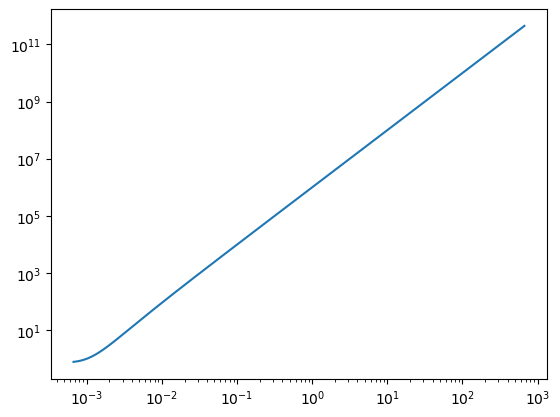

In [225]:
h = 2/3
k_size = 500
k_min = 1e-3*h
k_max = 1000.*h

k = np.logspace(np.log10(k_min),np.log10(k_max), k_size)
k_const = np.ones(k_size) * 1e-2

k1_vec = np.zeros((k_size, 3))
k2_vec = np.zeros((k_size, 3))
q_vec = np.zeros((k_size, 3))

k1_vec[:, 0] = k_const/10.
k1_vec[:, 1] = -k_const/10.
k2_vec[:, 0] = -k_const*40
k2_vec[:, 1] = k_const**2
k2_vec[:, 2] = -np.sqrt(k_const)/13.
k3_vec = -k1_vec -k2_vec
q_vec[:, 0] = k
q_vec[:, 1] = 0. # k**1.5*17.
q_vec[:, 2] = k # np.sqrt(k)/3.



k12 = abs_sq(k1_vec)
k22 = abs_sq(k2_vec)
k32 = abs_sq(- k1_vec - k2_vec)
q2  = abs_sq(q_vec)
k1mq2  = abs_sq(k1_vec - q_vec)
k2pq2  = abs_sq(k2_vec + q_vec)
k3mq2  = abs_sq(k3_vec - q_vec)

plt.plot(k, k1mq2/k12)
plt.yscale("log")
plt.xscale("log")


# $F_2$

factor =  102789043259.12544


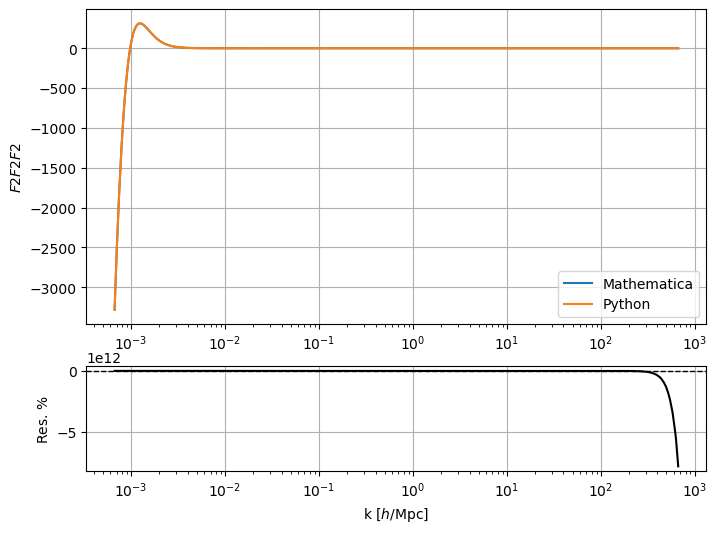

In [226]:
def F2(q1, q2):
    terms = 10 + 3* abs_sq(q1+q2)/abs_sq(q1) + 3* abs_sq(q1+q2)/abs_sq(q2) - 5* abs_sq(q1)/abs_sq(q2) - 5* abs_sq(q2)/abs_sq(q1) + 2* abs_sq(q1+q2)**2/( abs_sq(q1)*abs_sq(q2))
    return terms/28



# f2s1 = PreSimpKernel @ F2s[q, k1-q];
# f2s2 = PreSimpKernel @ F2s[k1-q, k2+q];
# f2s3 = PreSimpKernel @ F2s[k2+q,-q];
file_dir = dir+"/B222_kernels.dat"
F2F2F2 = get_F(file_dir, k12, k22, k32, q2, k1mq2, k2pq2, k3mq2)
F2F2F2_ref = F2(q_vec, k1_vec-q_vec) * F2(k1_vec-q_vec, k2_vec+q_vec) * F2(k2_vec+q_vec, -q_vec)


compare(k, F2F2F2, F2F2F2_ref, "Mathematica", "Python", "F2F2F2")

# $F_3$

In [227]:
dir = "/Users/fynn/Desktop/Uni/Master/Masters-thesis/04 Mathematica/0 kernels"

def F3(q1, q2, q3):
    q12 = dot(q1, q1)
    q22 = dot(q2, q2)
    q32 = dot(q3, q3)
    q1q2 = dot(q1, q2)
    q2q3 = dot(q2, q3)
    q3q1 = dot(q3, q1)
    line1 = ( q1q2 * abs_sq(q1+q2)/21. + q22*dot(q1, q1+q2)/14. ) / (3.*q12*q22*q32 * abs_sq(q1+q2))
    line2 = 7.*q32* dot(q1+q2,q1+q2+q3) + dot(q3, q1+q2) * abs_sq(q1+q2+q3)
    line3 = (dot(q1, q2+q3)*abs_sq(q1+q2+q3))/(3.*q12*q22*q32 * abs_sq(q2+q3)) * (q2q3*abs_sq(q2+q3)/21. + q32*dot(q2, q2+q3)/14.)
    line4 = dot(q1, q1+q2+q3)/(18*q12*q22*q32) * (q2q3 * abs_sq(q2+q3) + 5.*q32 * dot(q2, q2+q3))
    return line1*line2 + line3 + line4

def F3s(q1, q2, q3):
    return (F3(q1, q2, q3) + F3(q1, q3, q2) + F3(q2, q1, q3) + F3(q2, q3, q1) + F3(q3, q1, q2) + F3(q3, q2, q1))/6.

exp_file_1      = dir + "/f3simple1_real_exps.csv"
coeff_file_1    = dir + "/f3simple1_real_coeffs.csv"

exp_file_2      = dir + "/f3simple2_real_exps.csv"
coeff_file_2    = dir + "/f3simple2_real_coeffs.csv"


#F3_1 = get_F(exp_file_1, coeff_file_1, k12, k22, k32, q2, k1mq2, k2pq2, k3mq2)
#F3_2 = get_F(exp_file_2, coeff_file_2, k12, k22, k32, q2, k1mq2, k2pq2, k3mq2)
#F3_3 = F3(q_vec, -k2_vec - q_vec, -k1_vec)

#compare(k/h, F3_1, F3_2, "Fynn", "paper", "F_3")
#compare(k/h, F3_3, F3_2, "python", "paper", "F_3")
#compare(k/h, F3_3, F3_1, "python", "Fynn", "F_3")



# $F_3(q,-k_2-q,-k1)$ $F_2(-q, k_2+q)$

[-1.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
  0.00000000e+00  0.00000000e+00  1.00000000e+00  8.26719577e-04]
[-1.          0.          0.          1.          0.          0.
  0.          0.00661376]
[-1.          0.          0.          2.          0.         -1.
  0.         -0.00454696]
[-1.00000000e+00  0.00000000e+00  0.00000000e+00  2.00000000e+00
  0.00000000e+00 -1.00000000e+00  1.00000000e+00 -1.65343915e-03]
[-1.         0.         0.         0.         0.         1.
  1.         0.0020668]
[-1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  1.00000000e+00  0.00000000e+00 -8.26719577e-04]
[-1.00000000e+00  0.00000000e+00  0.00000000e+00 -1.00000000e+00
  0.00000000e+00  2.00000000e+00  1.00000000e+00 -1.24007937e-03]
[-1.00000000e+00  0.00000000e+00  0.00000000e+00 -1.00000000e+00
  0.00000000e+00  2.00000000e+00  0.00000000e+00 -1.24007937e-03]
[-1.00000000e+00  0.00000000e+00  0.00000000e+00  2.00000000e+00
 -2.00000000e+

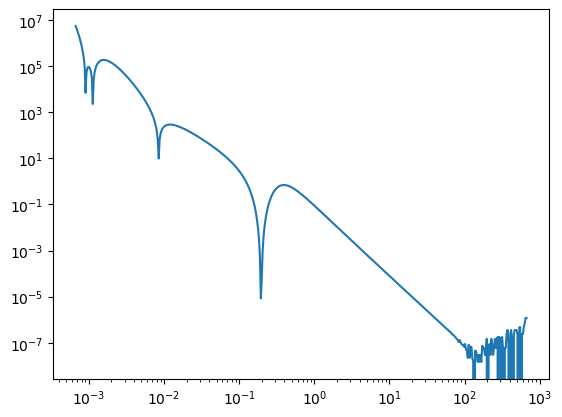

In [228]:
dir = '/Users/fynn/Desktop/Uni/Master/Masters-thesis/04 Mathematica/0 Kernels/kernels_real/data'


#F3F2_python = F3s(q_vec, -k2_vec-q_vec, -k1_vec) * F2(-q_vec, k2_vec+q_vec)
#F3F2_math = get_F(dir+"/B321_kernels.dat", k12, k22, k32, q2, k1mq2, k2pq2, k3mq2)

#F3s_python = F3s(q_vec, -k2_vec-q_vec, -k1_vec)
#F3s_math = get_F(dir+"/F3s_kernels.dat", k12, k22, k32, q2, k1mq2, k2pq2, k3mq2)


F3s_UV, list = get_F_UV(dir+"/B321_kernels.dat", k12, k22, k32, q2, k1mq2, k2pq2, k3mq2)

for _ in list:
    print(_)

plt.plot(k, np.abs(F3s_UV))

plt.yscale("log")
plt.xscale("log")
#plt.plot(k, F3s_python)
#compare(k, F3F2_math, F3F2_python, "Mathematica", "Python", "F3F2")